NMF (Non-Negative Matrix Factorization)

In [1]:
!pip install gensim

import sys
import re, numpy as np, pandas as pd
from pprint import pprint
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

# Gensim
import gensim, spacy, logging, warnings
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel
from gensim.models import Phrases
from gensim.models.phrases import Phraser

# NLTK Stop words
from spacy.lang.en.stop_words import STOP_WORDS
stop_words = STOP_WORDS
stop_words.update(['from', 'subject', 're', 'edu','etl', 'use','floor','debonair','instal','not','spite','wall','paint','event','prop','count','bed', 'pillow','would', 'say', 'could', '_', 'be', 'know', 'good', 'go', 'get', 'do', 'done', 'try', 'many', 'some', 'nice', 'thank', 'think', 'see', 'rather', 'easy', 'easily', 'lot', 'lack', 'make', 'want', 'seem', 'run', 'need', 'even','train' ,'right', 'line', 'even', 'featurecasual','also', 'may', 'take', 'come'])

%matplotlib inline
warnings.filterwarnings("ignore",category=DeprecationWarning)
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.ERROR)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 14.4 MB/s eta 0:00:00


In [ ]:
# Import Dataset
df = pd.read_excel("https://raw.githubusercontent.com/LS-Flerus/AI-Powered-ESG-Analysis-Replication/main/Data/TopicModeling/Company_Data__.xlsx")
print(df.shape)
df.head()


Mounted at /content/drive
(82, 3)


,Company names,Text,CertLevel
0,A&G,"""Safety & Compliance Our Strengths are: Pinaki...",Not Certified
1,AKH echo,"""CSR Approaches Towards Sustainable Industry I...",Gold
2,Akij jute,"""Bright & meritorious Students Scholarship pro...",Not Certified
3,Alphaclothing,Corporate Social Responsibility At Alpha Cloth...,Gold
4,Aman text limited,CSR – Aman Group Ltd +8809612613000info@amangr...,Platinum


In [3]:
def sent_to_words(sentences):
    for sent in sentences:
        sent = re.sub('\S*@\S*\s?', '', sent)  # remove emails
        sent = re.sub('\s+', ' ', sent)  # remove newline chars
        sent = re.sub("\'", "", sent)  # remove single quotes
        sent = gensim.utils.simple_preprocess(str(sent), deacc=True)
        yield(sent)

# Convert to list
data = df.Text.values.tolist()
data_words = list(sent_to_words(data))
print(data_words[:1])

[['safety', 'compliance', 'our', 'strengths', 'are', 'pinaki', 'is', 'compliant', 'manufacturing', 'company', 'fire', 'exits', 'and', 'sufficient', 'fire', 'protection', 'are', 'in', 'place', 'on', 'each', 'floor', 'all', 'workers', 'are', 'over', 'years', 'minimum', 'wages', 'are', 'guaranteed', 'for', 'all', 'workers', 'no', 'forced', 'labour', 'overtime', 'is', 'voluntary', 'no', 'women', 'are', 'deployed', 'in', 'the', 'use', 'of', 'heavy', 'machinery', 'first', 'aid', 'facilities', 'are', 'available', 'in', 'each', 'department', 'the', 'factory', 'premises', 'are', 'smoking', 'free', 'each', 'floor', 'is', 'well', 'ventilated', 'boilers', 'and', 'generator', 'are', 'conveniently', 'located', 'in', 'safe', 'zones', 'in', 'the', 'factory', 'area', 'pure', 'drinking', 'water', 'supply', 'is', 'available', 'upkeep', 'of', 'proper', 'methods', 'for', 'materials', 'safety', 'are', 'in', 'place', 'regularly', 'maintained', 'automatic', 'fire', 'detection', 'systems', 'exist', 'fire', 'do

<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2521/4049406598.py:3: SyntaxWarning: invalid escape sequence '\S'
  sent = re.sub('\S*@\S*\s?', '', sent)  # remove emails
/tmp/ipykernel_2521/4049406598.py:4: SyntaxWarning: invalid escape sequence '\s'
  sent = re.sub('\s+', ' ', sent)  # remove newline chars


In [4]:


# Build the bigram and trigram models
bigram = Phrases(data_words, min_count=5, threshold=100)  # higher threshold means fewer phrases
trigram = Phrases(bigram[data_words], threshold=100)

# Construct Phraser models
bigram_mod = Phraser(bigram)
trigram_mod = Phraser(trigram)


In [5]:
def process_words(texts, stop_words=stop_words, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV']):
    """Remove Stopwords, Form Bigrams, Trigrams, Lemmatization and remove Proper Nouns"""
    texts = [[word for word in simple_preprocess(str(doc)) if word not in stop_words] for doc in texts]
    texts = [bigram_mod[doc] for doc in texts]
    texts = [trigram_mod[bigram_mod[doc]] for doc in texts]
    texts_out = []
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
    for sent in texts:
        doc = nlp(" ".join(sent))
        texts_out.append([token.lemma_ for token in doc if token.pos_ in allowed_postags and token.pos_ != 'PROPN'])
    # remove stopwords once more after lemmatization
    texts_out = [[word for word in simple_preprocess(str(doc)) if word not in stop_words] for doc in texts_out]
    return texts_out


data_ready = process_words(data_words)

In [6]:
# Join the preprocessed words into a single string for each document
processed_texts = [" ".join(text) for text in data_ready]

# Initialize TfidfVectorizer without additional stop words since they are already removed
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, ngram_range=(1, 1))

# Transform the preprocessed text data into a TF-IDF matrix
tfidf = tfidf_vectorizer.fit_transform(processed_texts)



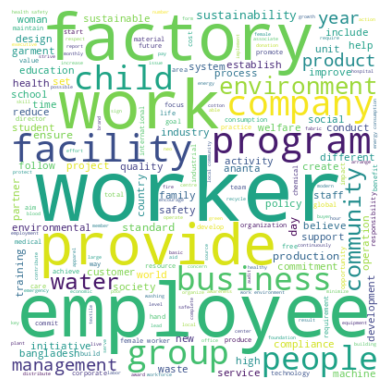

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_texts = ' '.join(processed_texts)

wordcloud = WordCloud(background_color='white', max_words=200, contour_width=3, contour_color='steelblue', width=400, height=400)

# Generate the word cloud from all combined texts
wordcloud.generate(all_texts)

# Display the word cloud using matplotlib
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


In [8]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# Since LDA works better with count data, we have created a CountVectorizer with the same parameters as TfidfVectorizer
count_vectorizer = CountVectorizer(max_df=0.95, min_df=2, ngram_range=(1, 1))
dtm_tf = count_vectorizer.fit_transform(processed_texts)

# Number of topics
n_topics = 4

# Create LDA model
lda_model = LatentDirichletAllocation(n_components=n_topics, random_state=0)

# Fit the model to the document term matrix
lda_model.fit(dtm_tf)

def display_topics(model, feature_names, no_top_words):
    """Function to display the topics and their top words"""
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

no_top_words = 10
display_topics(lda_model, count_vectorizer.get_feature_names_out(), no_top_words)


Topic 0:
program school foundation worker provide energy student water free donate
Topic 1:
worker employee provide work health facility environment people child community
Topic 2:
worker company management water work business environmental factory sustainability staff
Topic 3:
water worker safety facility fire group system environment employee environmental


In [9]:
from gensim import corpora
from gensim.models.ldamodel import LdaModel
from gensim.models.coherencemodel import CoherenceModel


# Step 2: Create Dictionary and Corpus
dictionary = corpora.Dictionary(data_ready)
corpus = [dictionary.doc2bow(text) for text in data_ready]

# Step 3: LDA Model with Gensim
lda_model_gensim = LdaModel(corpus=corpus, id2word=dictionary, num_topics=10, random_state=100, update_every=1, chunksize=100, passes=10, alpha='auto', per_word_topics=True)

# Step 4: Calculating Coherence Score (c_v)
coherence_model_lda = CoherenceModel(model=lda_model_gensim, texts=data_ready, dictionary=dictionary, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print('\nCoherence Score: ', coherence_lda)



Coherence Score:  0.37566861731868256


In [10]:
# Number of topics to extract
n_topics = 4

# Initialize NMF model
nmf_model = NMF(n_components=n_topics,random_state=42)

# Apply NMF on the TF-IDF matrix
nmf_topic_matrix = nmf_model.fit_transform(tfidf)

# Define a function to display the top n words for each topic
def display_topics(model, feature_names, n_words):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_words - 1:-1]]
        topics.append("Topic %d: %s" % (topic_idx, ", ".join(top_words)))
    return topics

# Display the top 10 words for each topic
top_n_words = 10
topics = display_topics(nmf_model, tfidf_vectorizer.get_feature_names_out(), top_n_words)
topics

['Topic 0: worker, safety, fire, facility, employee, maintain, provide, compliance, factory, medical',
 'Topic 1: sustainability, water, environmental, business, reduce, environment, energy, waste, product, sustainable',
 'Topic 2: program, worker, school, provide, health, education, support, student, child, free',
 'Topic 3: art, pediatric, burn, appointment, unit, people, intensive, state, competition, care']

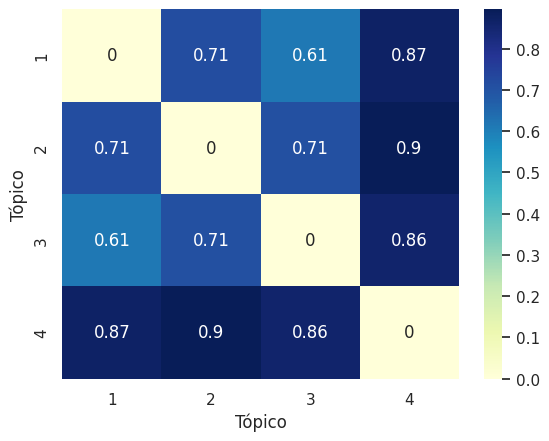

In [42]:
topic_vectors = nmf_model.components_

# Calculate pairwise distances between topic vectors
distances = squareform(pdist(topic_vectors, 'cosine'))

# Create a heatmap for the distance matrix
sns.heatmap(distances, annot=True, cmap='YlGnBu',xticklabels=np.arange(1, len(topic_vectors) + 1), yticklabels=np.arange(1, len(topic_vectors) + 1))

plt.xlabel('Tópico')
plt.ylabel('Tópico')
plt.show()

In [12]:
#Display all words
def display_topics(model, feature_names):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[::-1]]
        topics.append("Topic {}: {}".format(topic_idx, ", ".join(top_words)))
    return topics

topics = display_topics(nmf_model, tfidf_vectorizer.get_feature_names_out())
for topic in topics:
    print(topic)


Topic 0: worker, safety, fire, facility, employee, maintain, provide, compliance, factory, medical, sufficient, work, system, emergency, company, safe, free, electric, ensure, hour, hygienic, quality, exit, place, day, available, law, staff, health, center, chemical, training, centre, proper, working, aid, care, insurance, smoke, female, awareness, wear, handle, labor, water, production, designate, work_station, heavy_material, dining, personnel, equip, design, separate, management, level, child, nurse, detector, time, equipment, protection, wage, benefit, doctor, light, pure_drinke, strictly, force, environment, overtime, develop, welfare, hydrant, distribution, social, detection, include, workforce, baby, standard, control, pay, supply, break, respect, group, national, hall, conduct, regularly, product, regular, prayer, alarm, pump, door, zone, area, friendly, human, color, regulation, rule, view, evacuation, customer, adequate, offer, stair, ventilate, complete, pfl, lifestyle, issu

In [15]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plotly_top_words_(model, feature_names, n_words, n_topics):
    cols = n_topics
    subplot_width = 330
    total_width = subplot_width * cols

    subplot_height = max(400, n_words * 20)

    fig = make_subplots(
        rows=1,
        cols=cols,
        subplot_titles=[f'Topic {i+1}' for i in range(n_topics)],
        horizontal_spacing=0.08
    )

    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-n_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        fig.add_trace(
            go.Bar(
                x=weights,
                y=top_features,
                orientation='h',
                marker=dict(color=weights, coloraxis="coloraxis")
            ),
            row=1, col=topic_idx+1
        )

        max_weight = weights[0]
        fig.update_xaxes(range=[0, max_weight * 1.1], row=1, col=topic_idx+1)

        fig.update_yaxes(
            autorange="reversed",
            automargin=True,
            row=1,
            col=topic_idx+1
        )

    fig.update_layout(
        coloraxis=dict(colorscale='Blues'),
        showlegend=False,
        height=subplot_height,
        width=total_width,
        title_x=0.5,
        margin=dict(l=20, r=20, t=50, b=20)
    )

    fig.show()



plotly_top_words_(nmf_model, tfidf_vectorizer.get_feature_names_out(), 15, n_topics)


In [16]:
import plotly.express as px

def plotly_topic_distribution(topic_matrix,
                              width=560, height=340,
                              tick_size=20, text_size=18,
                              add_headroom=1.25):
    # dominant topic per doc
    doc_topic = np.argmax(topic_matrix, axis=1)
    counts = np.bincount(doc_topic, minlength=topic_matrix.shape[1])
    topics = [f"Topic {i+1}" for i in range(len(counts))]

    fig = px.bar(x=topics, y=counts,
                 labels={'x': 'Topic', 'y': 'Number of Companies'},
                 text=counts)


    fig.update_traces(
        textposition='outside',
        textfont=dict(size=text_size),
        hovertemplate='<b>%{x}</b><br>Number of Companies: %{y}<extra></extra>'
    )


    y_max = counts.max() if counts.size else 0
    fig.update_yaxes(range=[0, y_max * add_headroom if y_max > 0 else 1],
                     tickfont=dict(size=tick_size))
    fig.update_xaxes(tickfont=dict(size=tick_size))


    fig.update_layout(
        width=width, height=height,
        bargap=0.35,
        margin=dict(l=60, r=20, t=40, b=60),
        uniformtext_minsize=text_size,
        uniformtext_mode='show'
    )

    fig.show()


plotly_topic_distribution(nmf_topic_matrix, width=560, height=330, tick_size=20, text_size=18)


In [17]:
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
from gensim.models.nmf import Nmf

df['Processed_Text'] = processed_texts
# Tokenize the processed text for gensim
texts = [text.split() for text in df['Processed_Text']]

# Create a dictionary representation
dictionary = Dictionary(texts)

# Convert the tokenized texts into a bag-of-words corpus
corpus = [dictionary.doc2bow(text) for text in texts]

# Gensim's NMF model for coherence computation
gensim_nmf = Nmf(corpus, num_topics=n_topics,passes=5,minimum_probability=0, id2word=dictionary, random_state=42,eval_every=10,chunksize=1000)

# Compute coherence score
coherence_model = CoherenceModel(model=gensim_nmf, texts=texts, dictionary=dictionary, coherence='c_v')
coherence_score = coherence_model.get_coherence()

coherence_score

np.float64(0.3127487685200425)

In [18]:
!pip install nltk


### **Extracting relevant sentences**

In [19]:
%pip -q install nltk
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')  # some NLTK versions require this too
from nltk.tokenize import sent_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [20]:
def display_topics1(model, feature_names, n_words):
    topics = {idx: [feature_names[i] for i in topic.argsort()[:-n_words - 1:-1]] for idx, topic in enumerate(model.components_)}
    return topics

top_n_words = 20
topics = display_topics1(nmf_model, tfidf_vectorizer.get_feature_names_out(), top_n_words)

# Function to extract relevant sentences
def extract_relevant_sentences(all_docs, topics):
    sentences_by_topic = {i: [] for i in topics}
    for doc in all_docs:
        sentences = sent_tokenize(doc)
        for sentence in sentences:
            lower_sentence = sentence.lower()
            for topic_id, keywords in topics.items():
                if any(re.search(r'\b' + re.escape(keyword) + r'\b', lower_sentence) for keyword in keywords):
                    sentences_by_topic[topic_id].append(sentence)
    return sentences_by_topic

# Extract sentences for each topic
relevant_sentences = extract_relevant_sentences(df['Text'].tolist(), topics)

# Print the top 12 keywords for each topic
for topic_id, keywords in topics.items():
    print(f"Topic {topic_id}: {keywords}")
print('\n')
# Print the relevant sentences
for topic_id, sentences in relevant_sentences.items():
    print(f"Topic {topic_id}: {sentences[:10]}")

Topic 0: ['worker', 'safety', 'fire', 'facility', 'employee', 'maintain', 'provide', 'compliance', 'factory', 'medical', 'sufficient', 'work', 'system', 'emergency', 'company', 'safe', 'free', 'electric', 'ensure', 'hour']
Topic 1: ['sustainability', 'water', 'environmental', 'business', 'reduce', 'environment', 'energy', 'waste', 'product', 'sustainable', 'group', 'work', 'customer', 'report', 'consumption', 'initiative', 'community', 'goal', 'production', 'standard']
Topic 2: ['program', 'worker', 'school', 'provide', 'health', 'education', 'support', 'student', 'child', 'free', 'employee', 'year', 'project', 'community', 'scholarship', 'donate', 'foundation', 'start', 'group', 'poor']
Topic 3: ['art', 'pediatric', 'burn', 'appointment', 'unit', 'people', 'intensive', 'state', 'competition', 'care', 'responsibility', 'child', 'mechanical', 'neighborhood', 'proactively', 'conditioner', 'picture', 'promptly', 'artwork', 'relationnew']


Topic 0: ['"Safety & Compliance Our Strengths are

### **Centrality Analysis**

In [21]:
from collections import defaultdict
import networkx as nx
from itertools import combinations

In [22]:

feature_names = tfidf_vectorizer.get_feature_names_out()

def display_topics2(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print("Topic %d:" % (topic_idx + 1))
        print(", ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

print("\n")
# Number of words to display per topic
no_top_words = 15

feature_names = tfidf_vectorizer.get_feature_names_out()
topics_words = {idx: [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]] for idx, topic in enumerate(nmf_model.components_)}

# Define a minimum co-occurrence threshold to consider for edge creation
min_co_occurrence = 5

# Create a co-occurrence matrix for each topic
topic_co_occurrence_matrices = defaultdict(lambda: defaultdict(int))
for topic_idx, words in topics_words.items():
    for doc in data_ready:

        doc_words = set(word for word in doc if word in words)
        for w1, w2 in combinations(doc_words, 2):
            if w1 != w2:
                topic_co_occurrence_matrices[topic_idx][(w1, w2)] += 1

# Calculate degree, closeness, and eigenvector centrality for each word in each topic
centrality_measures = defaultdict(lambda: {"degree": {}, "closeness": {}, "eigenvector": {}})
for topic_idx, co_occ_matrix in topic_co_occurrence_matrices.items():
    G = nx.Graph()
    for (w1, w2), weight in co_occ_matrix.items():
        if weight >= min_co_occurrence:
            G.add_edge(w1, w2, weight=weight)
    degree_centrality = nx.degree_centrality(G)
    closeness_centrality = nx.closeness_centrality(G)
    try:
        eigenvector_centrality = nx.eigenvector_centrality_numpy(G, weight='weight')
    except nx.NetworkXError as e:
        print(f"Error in computing eigenvector centrality for topic {topic_idx}: {e}")
        eigenvector_centrality = {}
    centrality_measures[topic_idx]["degree"] = degree_centrality
    centrality_measures[topic_idx]["closeness"] = closeness_centrality
    centrality_measures[topic_idx]["eigenvector"] = eigenvector_centrality

# Print the top words by centrality measures for each topic
for topic_idx, measures in centrality_measures.items():
    display_idx = topic_idx + 1
    print(f"Centrality measures for Topic {display_idx}:")
    print("\n")
    print("Top words by degree centrality:")
    sorted_degree = sorted(measures["degree"].items(), key=lambda item: item[1], reverse=True)
    for word, centrality_score in sorted_degree[:15]:
        print(f"{word}: {centrality_score:.4f}")
    print("\n")
    print("Top words by closeness centrality:")
    sorted_closeness = sorted(measures["closeness"].items(), key=lambda item: item[1], reverse=True)
    for word, centrality_score in sorted_closeness[:15]:
        print(f"{word}: {centrality_score:.4f}")
    print("\n")
    print("Top words by eigenvector centrality:")
    sorted_eigenvector = sorted(measures["eigenvector"].items(), key=lambda item: item[1], reverse=True)
    for word, centrality_score in sorted_eigenvector[:15]:
        print(f"{word}: {centrality_score:.3f}")
    print("\n")




Centrality measures for Topic 1:


Top words by degree centrality:
fire: 1.0000
system: 1.0000
emergency: 1.0000
safety: 1.0000
worker: 1.0000
medical: 1.0000
factory: 1.0000
compliance: 1.0000
provide: 1.0000
company: 1.0000
facility: 1.0000
maintain: 1.0000
work: 1.0000
employee: 0.9286
sufficient: 0.9286


Top words by closeness centrality:
fire: 1.0000
system: 1.0000
emergency: 1.0000
safety: 1.0000
worker: 1.0000
medical: 1.0000
factory: 1.0000
compliance: 1.0000
provide: 1.0000
company: 1.0000
facility: 1.0000
maintain: 1.0000
work: 1.0000
employee: 0.9333
sufficient: 0.9333


Top words by eigenvector centrality:
work: 0.368
facility: 0.336
worker: 0.284
safety: 0.274
factory: 0.270
employee: 0.262
provide: 0.260
company: 0.258
system: 0.253
medical: 0.243
fire: 0.234
maintain: 0.226
emergency: 0.209
compliance: 0.205
sufficient: 0.083


Centrality measures for Topic 2:


Top words by degree centrality:
environment: 1.0000
water: 1.0000
group: 1.0000
sustainability: 1.0000
wast

/tmp/ipykernel_2521/875995599.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




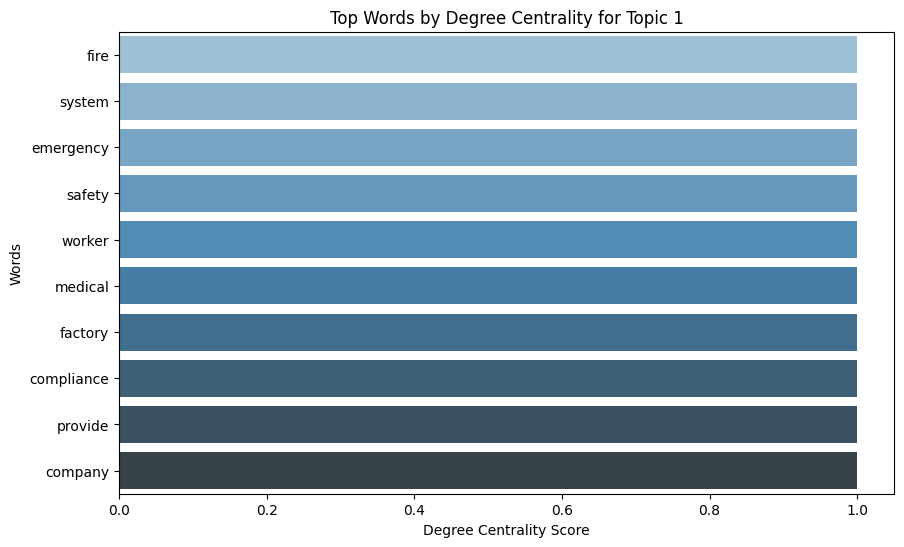

/tmp/ipykernel_2521/875995599.py:25: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




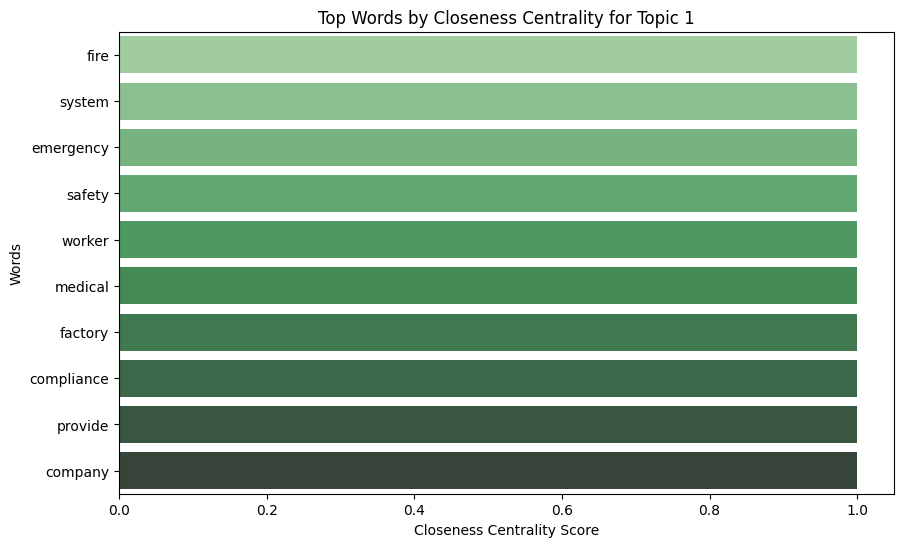

/tmp/ipykernel_2521/875995599.py:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




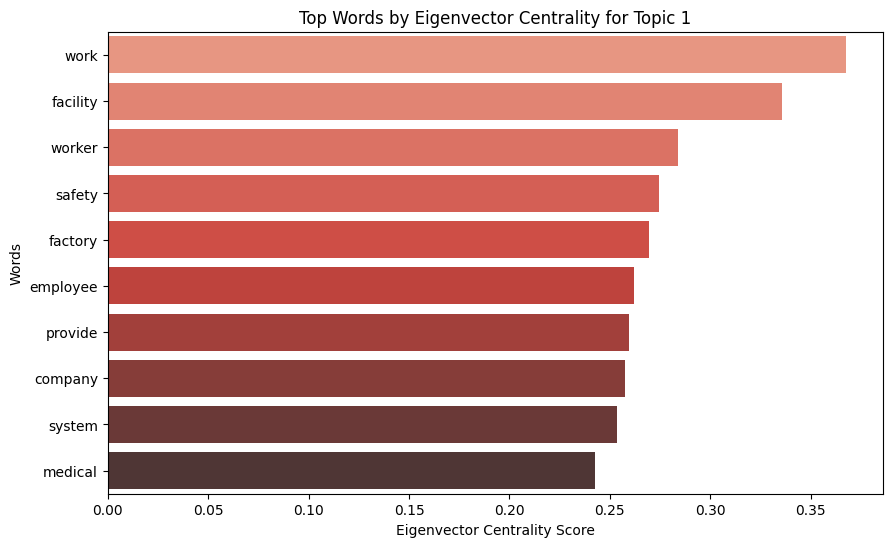

/tmp/ipykernel_2521/875995599.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




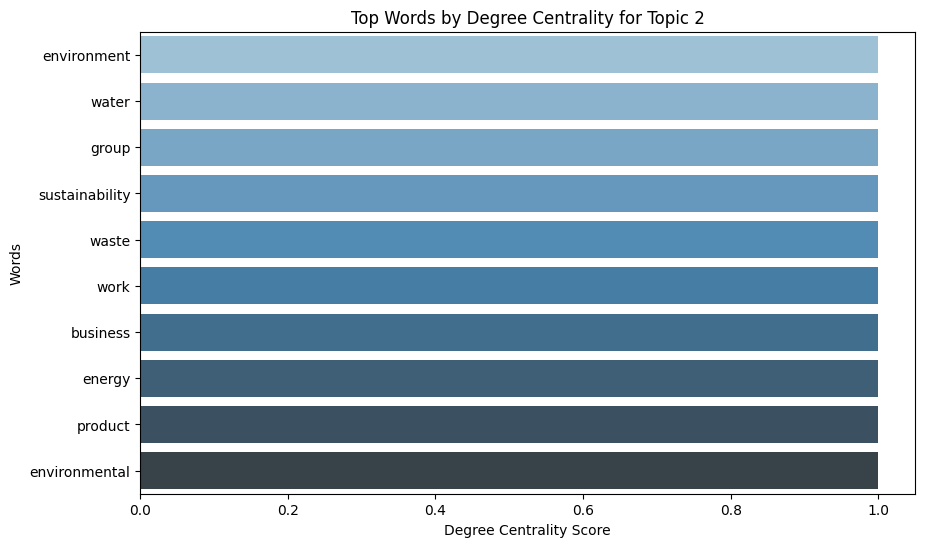

/tmp/ipykernel_2521/875995599.py:25: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




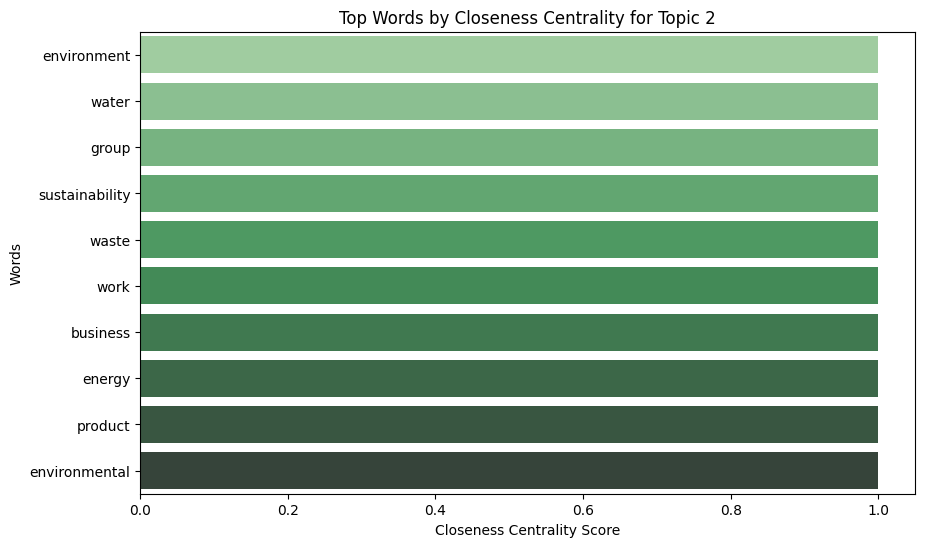

/tmp/ipykernel_2521/875995599.py:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




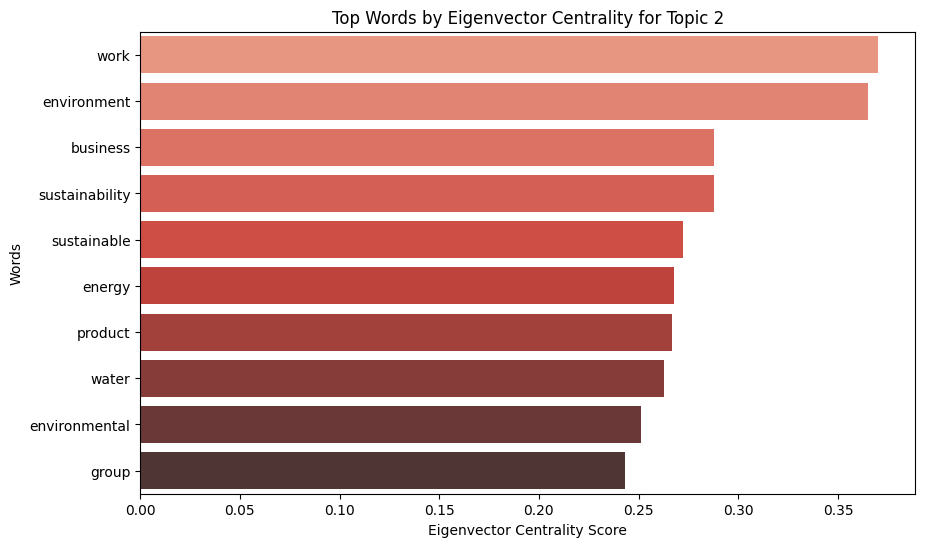

/tmp/ipykernel_2521/875995599.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




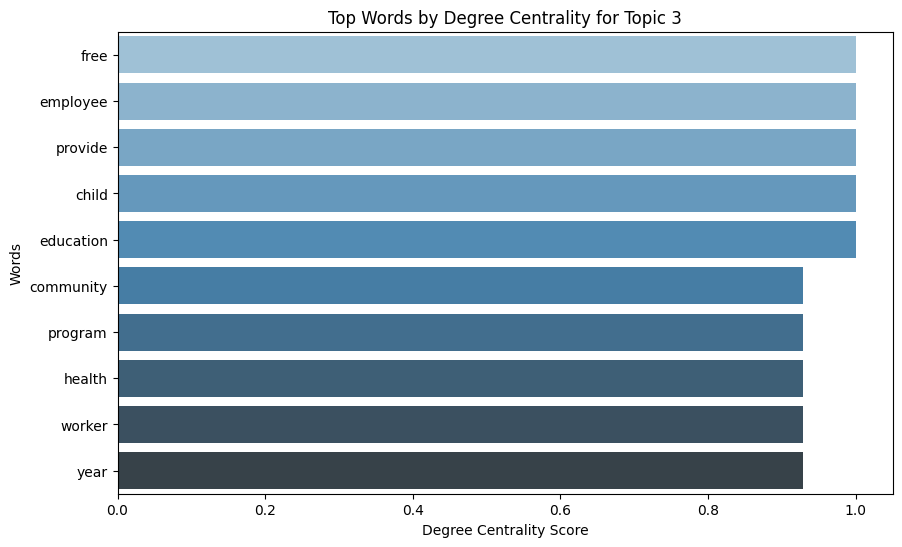

/tmp/ipykernel_2521/875995599.py:25: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




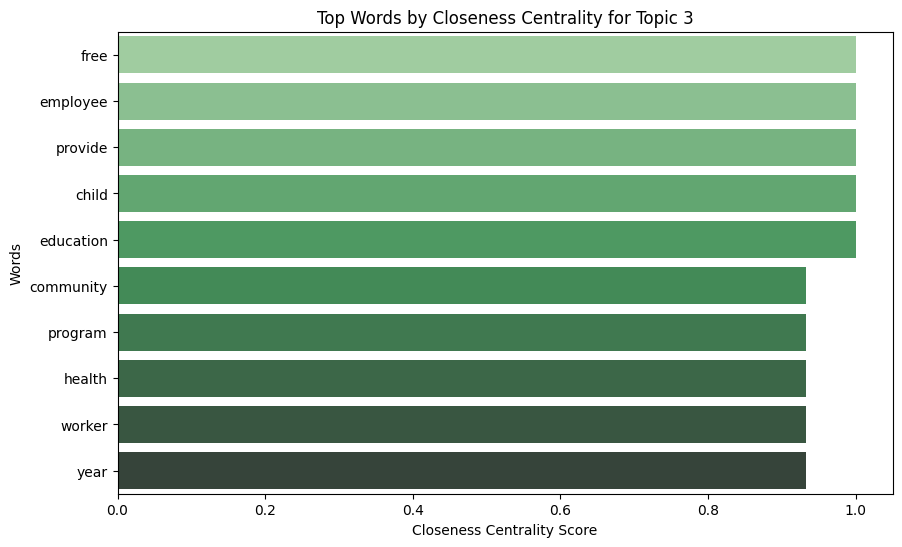

/tmp/ipykernel_2521/875995599.py:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




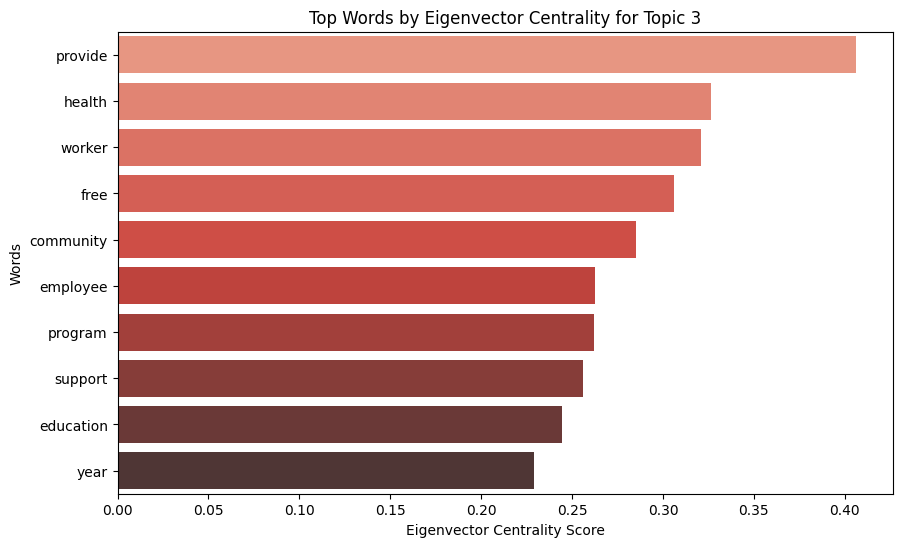

/tmp/ipykernel_2521/875995599.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




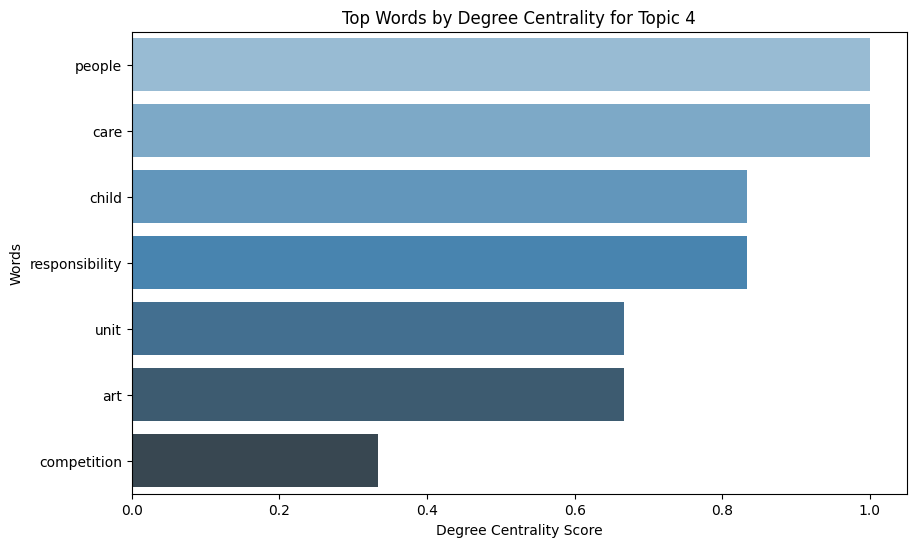

/tmp/ipykernel_2521/875995599.py:25: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




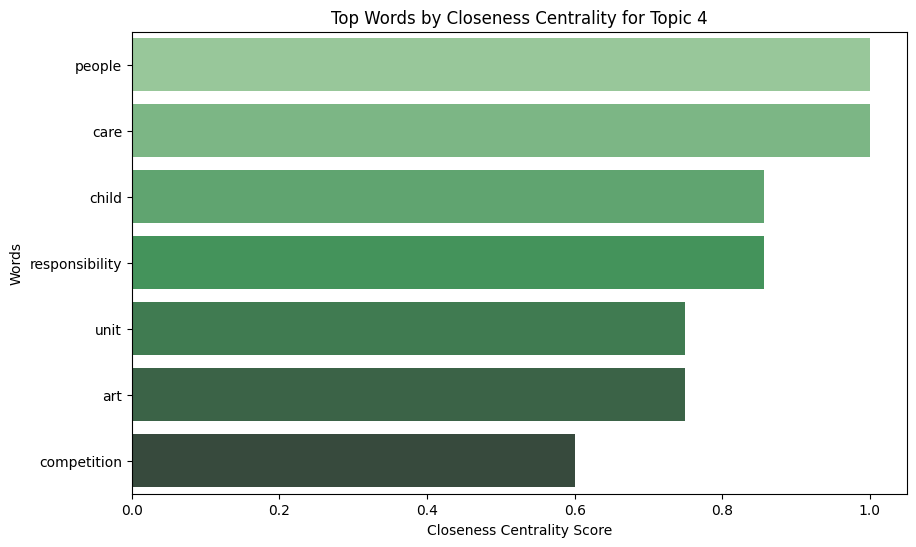

/tmp/ipykernel_2521/875995599.py:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




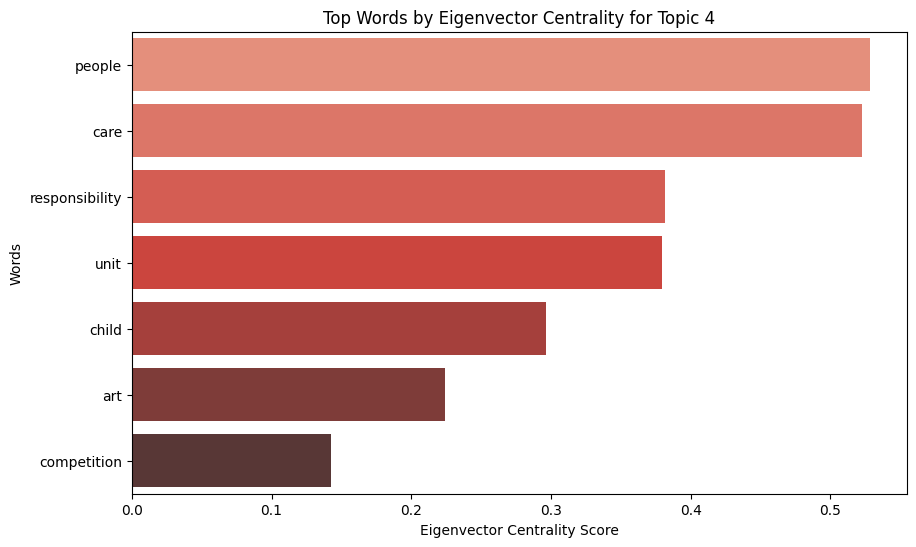

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_centrality_measures(centrality_measures, top_n=10):
    """
    Visualizes centrality measures (degree, closeness, eigenvector) as bar plots for each topic.
    """
    for topic_idx, measures in centrality_measures.items():
        display_idx = topic_idx + 1

        # --- Bar Plot for Degree Centrality ---
        plt.figure(figsize=(10, 6))
        sorted_degree = sorted(measures["degree"].items(), key=lambda item: item[1], reverse=True)[:top_n]
        words, scores = zip(*sorted_degree)
        sns.barplot(x=scores, y=words, palette='Blues_d')
        plt.title(f'Top Words by Degree Centrality for Topic {display_idx}')
        plt.xlabel('Degree Centrality Score')
        plt.ylabel('Words')
        plt.show()

        # --- Bar Plot for Closeness Centrality ---
        plt.figure(figsize=(10, 6))
        sorted_closeness = sorted(measures["closeness"].items(), key=lambda item: item[1], reverse=True)[:top_n]
        words, scores = zip(*sorted_closeness)
        sns.barplot(x=scores, y=words, palette='Greens_d')
        plt.title(f'Top Words by Closeness Centrality for Topic {display_idx}')
        plt.xlabel('Closeness Centrality Score')
        plt.ylabel('Words')
        plt.show()

        # --- Bar Plot for Eigenvector Centrality ---
        plt.figure(figsize=(10, 6))
        sorted_eigenvector = sorted(measures["eigenvector"].items(), key=lambda item: item[1], reverse=True)[:top_n]
        words, scores = zip(*sorted_eigenvector)
        sns.barplot(x=scores, y=words, palette='Reds_d')
        plt.title(f'Top Words by Eigenvector Centrality for Topic {display_idx}')
        plt.xlabel('Eigenvector Centrality Score')
        plt.ylabel('Words')
        plt.show()

# Visualize centrality measures for each topic
visualize_centrality_measures(centrality_measures, top_n=10)


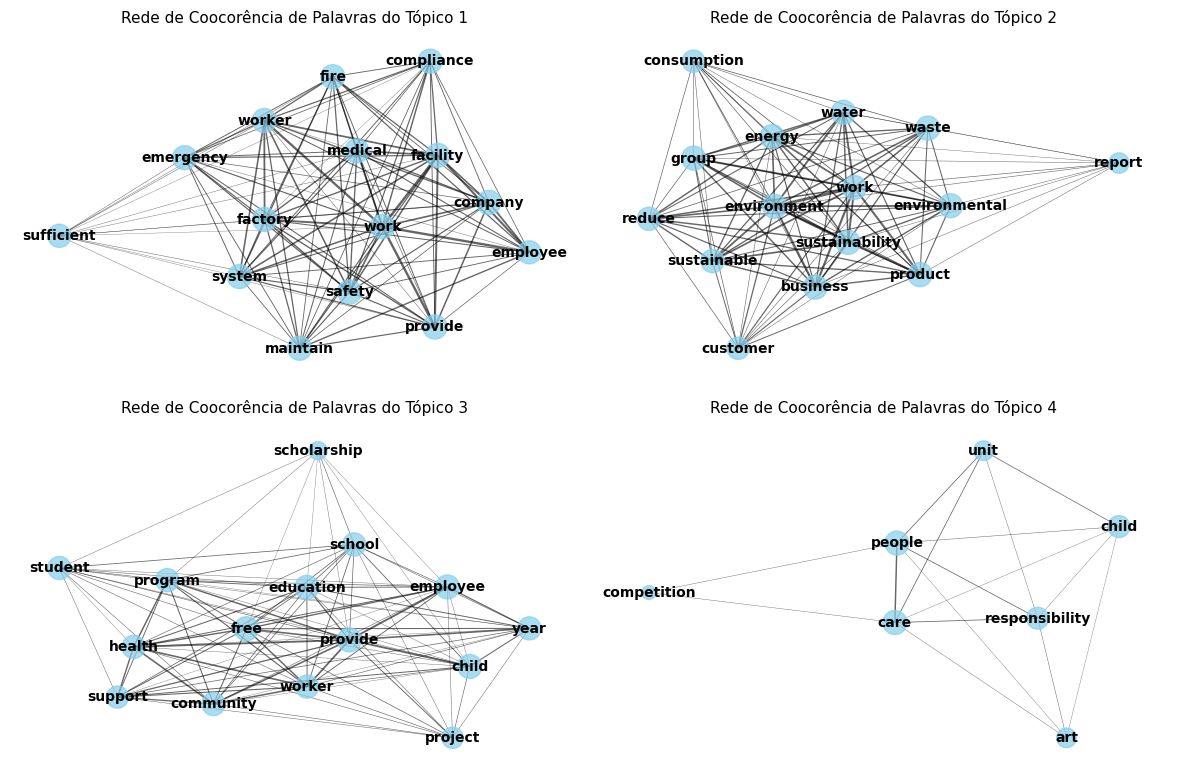

In [24]:
import matplotlib.pyplot as plt
import networkx as nx
from math import ceil

def visualize_word_co_occurrence_networks_2_columns_smaller(topic_co_occurrence_matrices, min_co_occurrence=5):

    num_topics = len(topic_co_occurrence_matrices)
    num_rows = ceil(num_topics / 2)

    fig, axes = plt.subplots(num_rows, 2, figsize=(12, num_rows * 4))
    axes = axes.flatten()

    for idx, (topic_idx, co_occ_matrix) in enumerate(topic_co_occurrence_matrices.items()):
        display_idx = topic_idx + 1

        G = nx.Graph()
        for (w1, w2), weight in co_occ_matrix.items():
            if weight >= min_co_occurrence:
                G.add_edge(w1, w2, weight=weight)

        pos = nx.spring_layout(G, k=0.5, seed=42)

        node_size = [v * 300 for v in nx.degree_centrality(G).values()]
        edge_width = [d['weight'] * 0.05 for (u, v, d) in G.edges(data=True)]

        ax = axes[idx]
        nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color='skyblue', alpha=0.7, ax=ax)
        nx.draw_networkx_edges(G, pos, width=edge_width, alpha=0.6, ax=ax)

        nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif", font_weight='bold', ax=ax)

        ax.set_title(f'Rede de Coocorência de Palavras do Tópico {display_idx}', fontsize=11)
        ax.axis('off')

    for i in range(idx + 1, len(axes)):
        axes[i].axis('off')

    plt.tight_layout(pad=1.5)
    plt.show()

# Visualize word co-occurrence networks for each topic in a more compact two-column layout
visualize_word_co_occurrence_networks_2_columns_smaller(topic_co_occurrence_matrices, min_co_occurrence=5)


/tmp/ipykernel_2521/1230252827.py:21: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.


/tmp/ipykernel_2521/1230252827.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_2521/1230252827.py:31: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.


/tmp/ipykernel_2521/1230252827.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_2521/1230252827.py:41: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.


/tmp/ipykernel_2521/1230252827.py:41: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the 

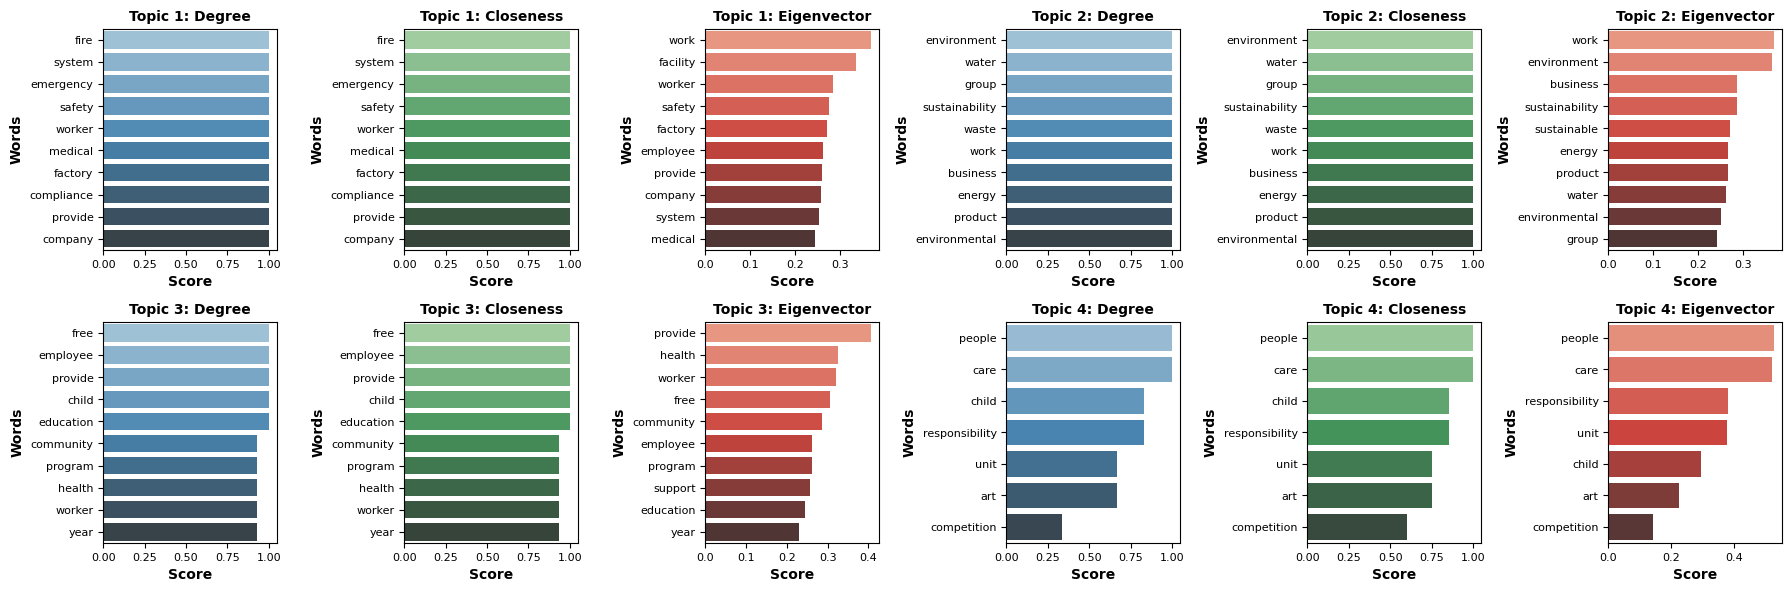

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_centrality_measures_grid_2x6(centrality_measures, top_n=10):
    """
    Visualizes centrality measures (degree, closeness, eigenvector) as bar plots for each topic
    in a compact 2x6 grid layout with improved axis label styling.
    """

    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    axes = axes.flatten()  # Flatten the 2D array of axes to 1D for easy iteration

    plot_idx = 0  # Initialize plot index

    for topic_idx, measures in centrality_measures.items():
        display_idx = topic_idx + 1

        # --- Bar Plot for Degree Centrality ---
        sorted_degree = sorted(measures["degree"].items(), key=lambda item: item[1], reverse=True)[:top_n]
        words, scores = zip(*sorted_degree)
        sns.barplot(x=scores, y=words, palette='Blues_d', ax=axes[plot_idx], ci=None)
        axes[plot_idx].set_title(f'Topic {display_idx}: Degree', fontsize=10, fontweight='bold')
        axes[plot_idx].set_xlabel('Score', fontsize=10, fontweight='bold')
        axes[plot_idx].set_ylabel('Words', fontsize=10, fontweight='bold')
        axes[plot_idx].tick_params(labelsize=8)
        plot_idx += 1

        # --- Bar Plot for Closeness Centrality ---
        sorted_closeness = sorted(measures["closeness"].items(), key=lambda item: item[1], reverse=True)[:top_n]
        words, scores = zip(*sorted_closeness)
        sns.barplot(x=scores, y=words, palette='Greens_d', ax=axes[plot_idx], ci=None)
        axes[plot_idx].set_title(f'Topic {display_idx}: Closeness', fontsize=10, fontweight='bold')
        axes[plot_idx].set_xlabel('Score', fontsize=10, fontweight='bold')
        axes[plot_idx].set_ylabel('Words', fontsize=10, fontweight='bold')
        axes[plot_idx].tick_params(labelsize=8)
        plot_idx += 1

        # --- Bar Plot for Eigenvector Centrality ---
        sorted_eigenvector = sorted(measures["eigenvector"].items(), key=lambda item: item[1], reverse=True)[:top_n]
        words, scores = zip(*sorted_eigenvector)
        sns.barplot(x=scores, y=words, palette='Reds_d', ax=axes[plot_idx], ci=None)
        axes[plot_idx].set_title(f'Topic {display_idx}: Eigenvector', fontsize=10, fontweight='bold')
        axes[plot_idx].set_xlabel('Score', fontsize=10, fontweight='bold')
        axes[plot_idx].set_ylabel('Words', fontsize=10, fontweight='bold')
        axes[plot_idx].tick_params(labelsize=8)
        plot_idx += 1

    # Hide any remaining empty subplots
    for i in range(plot_idx, len(axes)):
        axes[i].axis('off')

    # Adjust layout
    plt.tight_layout(pad=1.0)
    plt.show()

# Visualize centrality measures for each topic
visualize_centrality_measures_grid_2x6(centrality_measures, top_n=10)


In [26]:
count_vectorizer = CountVectorizer()
X = count_vectorizer.fit_transform([' '.join(text) for text in data_ready])
Xc = (X.T * X)  # This is the matrix multiplication step to get the co-occurrence matrix
Xc.setdiag(0)  # Set diagonals to 0

# Convert to CSV for NetDraw
co_occ_df = pd.DataFrame(Xc.toarray(), index=count_vectorizer.get_feature_names_out(), columns=count_vectorizer.get_feature_names_out())
edge_list = co_occ_df.stack().reset_index()
edge_list.columns = ['Source', 'Target', 'Weight']
edge_list = edge_list[edge_list['Weight'] > 0]  # Filter out zero weights
edge_list.to_csv('co_occurrence_edge_list.csv', index=False)